In [12]:
import os
from dotenv import load_dotenv

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

load_dotenv() 

True

In [13]:
class Task(BaseModel):
    id: int
    title: str
    brief: str 

In [14]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [15]:
class State(TypedDict):
    topic: str # user writes topic 
    plan: Plan # orchestrator will make plan
    # reducer: results from workers get concatenated automatically
    # each worker notes send string that we will store inside list
    sections: Annotated[List[str], operator.add] 
    final: str

In [16]:
llm = ChatGroq(model="qwen/qwen3.6-27b")

In [17]:
def orchestrator(state: State) -> dict:
    print("\n=== ORCHESTRATOR INPUT ===")
    print(state)

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content="Create a blog plan with 5-7 sections on the following topic."
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )

    print("\n=== ORCHESTRATOR OUTPUT ===")
    print(plan)

    return {"plan": plan}


In [18]:
# this function will check how many task we have and send a object to each worker node about their task, topic, plan
def fanout(state: State):
    print("\n=== FANOUT INPUT ===")
    print(state)

    sends = [
        Send(
            "worker",
            {
                "task": task,
                "topic": state["topic"],
                "plan": state["plan"]
            }
        )
        for task in state["plan"].tasks
    ]

    print("\n=== FANOUT OUTPUT ===")
    print(sends)

    return sends

In [19]:
def worker(payload: dict) -> dict:
    print("\n=== WORKER INPUT ===")
    print(payload)

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title   

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"   #!   <-  ? 
                    f"Brief: {task.brief}\n\n"   #!   <-  ?
                    "Return only the section content"
                )
            ),
        ]
    ).content.strip() # type: ignore

    print("\n=== WORKER OUTPUT ===")
    print(section_md)

    return {"sections": [section_md]}

In [20]:
from pathlib import Path

def reducer(state: State) -> dict:
    print("\n=== REDUCER INPUT ===")
    print(state)
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"
    print(final_md)
    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".html"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [21]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker) # type: ignore
g.add_node("reducer", reducer)

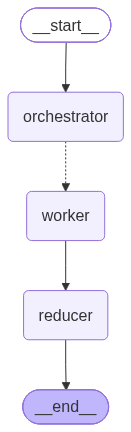

In [22]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [23]:
out = app.invoke({"topic": "Write a blog on Artificial Intelligence", "sections": []}) # type: ignore
out


=== ORCHESTRATOR INPUT ===
{'topic': 'Write a blog on Artificial Intelligence', 'sections': []}

=== ORCHESTRATOR OUTPUT ===
blog_title='Understanding Artificial Intelligence: A Comprehensive Guide' tasks=[Task(id=1, title='Introduction to Artificial Intelligence', brief='Define AI and explain its significance in modern technology.'), Task(id=2, title='A Brief History of AI', brief='Trace the evolution of AI from its conceptual beginnings to current advancements.'), Task(id=3, title='Types of Artificial Intelligence', brief='Explain the differences between Narrow AI, General AI, and Superintelligence.'), Task(id=4, title='Machine Learning and Deep Learning', brief='Describe how these subsets of AI work and how machines learn from data.'), Task(id=5, title='Real-World Applications of AI', brief='Highlight how AI is transforming industries like healthcare, finance, and transportation.'), Task(id=6, title='Ethical Considerations and Challenges', brief='Discuss issues such as data privacy

{'topic': 'Write a blog on Artificial Intelligence',
 'plan': Plan(blog_title='Understanding Artificial Intelligence: A Comprehensive Guide', tasks=[Task(id=1, title='Introduction to Artificial Intelligence', brief='Define AI and explain its significance in modern technology.'), Task(id=2, title='A Brief History of AI', brief='Trace the evolution of AI from its conceptual beginnings to current advancements.'), Task(id=3, title='Types of Artificial Intelligence', brief='Explain the differences between Narrow AI, General AI, and Superintelligence.'), Task(id=4, title='Machine Learning and Deep Learning', brief='Describe how these subsets of AI work and how machines learn from data.'), Task(id=5, title='Real-World Applications of AI', brief='Highlight how AI is transforming industries like healthcare, finance, and transportation.'), Task(id=6, title='Ethical Considerations and Challenges', brief='Discuss issues such as data privacy, algorithmic bias, and the impact on the workforce.'), Ta